## Summary

**Data:** Google Trends search data, World Bank macro indicators, and ILINet health time-series data.  
**Question:** How can online behavioral data be used to study macro-level patterns such as future orientation and public health trends?  
**Methods:** Data cleaning and merging, correlation analysis, visualization, and time-series modeling.  
**Key finding:** The notebook shows how digital trace data such as Google search behavior can be linked to both economic indicators and flu trends, combining search data with public datasets for empirical analysis.

<div style="text-align: center;" >
<h1 style="margin-top: 0.2em; margin-bottom: 0.1em;">Assignment 1</h1>
<h4 style="margin-top: 0.7em; margin-bottom: 0.3em; font-style:italic">
Commit your solutions to our 
<a href=''>GitHub Classroom TBA</a>
until May 1, 23:59</h4>
</div>
<br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Part 1
## Correlation of Future Orientation Index and Gross Domestic Product

### Tasks

In this exercise, we try to reproduce the findings of the article “Quantifying the Advantage of Looking Forward” http://www.nature.com/articles/srep00350.

According to the study, the GDP per capita of countries is positively correlated to how much their population searches in Google for the next year, relative to how much they search for the previous year.

This ratio is called the Future Orientation Index (FOI). So for example for the year 2017 the FOI can be calculated as: FOI = number of searches for the term “2018” / number of searches for the term “2016”.

You will do the following tasks:
1. Aquire World Bank Data
2. Calculate the Future Orientation Index in Google Trends
3. Test the correlation between GDP and FOI

### Install requirements

The following cell contains all the necessary dependencies needed for this task. If you run the cell everything will be installed.  
* [`wbgapi`](https://github.com/tgherzog/wbgapi) is a Python package which provides modern, pythonic access to the World Bank's data API. [Here](https://github.com/tgherzog/wbgapi) is the documentation of `wbgapi`.
* [`pandas`](https://pandas.pydata.org/docs/index.html) is a Python package for creating and working with tabular data. [Here](https://pandas.pydata.org/docs/reference/index.html) is the documentation of `pandas`.
* [`matplotlib`](https://matplotlib.org/) is a Python package for creating plots. [Here](https://matplotlib.org/stable/api/index.html) is the documentation of `matplotlib`.
* [`scipy`](https://scipy.org/) is a Python package with different algorithms for scientific computing. [Here](https://docs.scipy.org/doc/scipy/reference/index.html#scipy-api) is the documentation of `scipy`.

In [ ]:
#! pip install wbgapi
#! pip install pandas
#! pip install matplotlib
#! pip install scipy

### Exercise 1: World Bank Data *(3 points)*
#### 1.1 Download WDI data

From the WDI we need three indicators:
* Gross Domestic Product (GDP) per capita corrected by the Purchase Power Parity (PPP in current or 2005 international $, `"NY.GDP.PCAP.PP.KD"`)
* The amount of Internet users (per 100 people, `"IT.NET.USER.ZS"`
* The total population (described as as "Population, Total", `"SP.POP.TOTL"`)

In the following code chunk, download all data (including extras) for all countries in year 2014 and save it as a pandas data frame. See [here](https://github.com/tgherzog/wbgapi#accessing-data) how to use the `data` subpackage of `wbgapi`.

Hint: To remove aggregates (economic regions defined by the World Bank) and include only countries, use `skipAggs=True`.

In [2]:
import wbgapi as wb
import pandas as pd
import numpy as np

Now drop any row that has `NaN` for this you can use `pandas` [`dropna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html) method.

In [3]:
df = wb.data.DataFrame(["NY.GDP.PCAP.PP.KD", "IT.NET.USER.ZS", "SP.POP.TOTL"] , time=2014, skipBlanks=True, labels=True, skipAggs=True).reset_index()
df = df.dropna()
df

,economy,Country,IT.NET.USER.ZS,NY.GDP.PCAP.PP.KD,SP.POP.TOTL
0,ZWE,Zimbabwe,16.3647,5081.112404,14207359.0
1,ZMB,Zambia,6.5000,3585.577485,15895315.0
2,PSE,West Bank and Gaza,53.6652,5990.426615,4173398.0
3,VIR,Virgin Islands (U.S.),50.0700,42853.898660,107882.0
4,VNM,Viet Nam,41.0000,8751.882806,91679578.0
...,...,...,...,...,...
194,AGO,Angola,21.3623,11721.664416,27160769.0
195,AND,Andorra,86.1000,59929.244467,73737.0
196,DZA,Algeria,29.5000,15073.762940,39205031.0
197,ALB,Albania,54.3000,13366.559526,2773767.0


Next only keep rows where there are at least 5 Million internet users. Keep in Mind that the Internet Users are per 100 people, so don't forget to take the population into account.

For example in the dataset Austria has 80.995825 internet users per 100 people, while 8546356 people living in Austria. This means Austria has 6922191.55 internet users in total. The calculation for that is as follows:
<br>

$$
\begin{align}
internet\_users = population \cdot \frac{internet\_user\_per\_100}{100}
\end{align}
$$


In [4]:
df = df[(df["SP.POP.TOTL"] * df["IT.NET.USER.ZS"] / 100) >= 5000000]
df

,economy,Country,IT.NET.USER.ZS,NY.GDP.PCAP.PP.KD,SP.POP.TOTL
4,VNM,Viet Nam,41.0000,8751.882806,91679578.0
6,UZB,Uzbekistan,35.5000,7145.109807,30222994.0
8,USA,United States,73.0000,63018.803394,319257560.0
9,GBR,United Kingdom,91.6133,48964.286351,64620000.0
10,ARE,United Arab Emirates,90.4000,74145.109371,8059440.0
...,...,...,...,...,...
188,AUT,Austria,80.9958,60845.659773,8546356.0
189,AUS,Australia,84.0000,55489.068844,23475686.0
192,ARG,Argentina,64.7000,28200.815257,43024071.0
194,AGO,Angola,21.3623,11721.664416,27160769.0


### Exercise 2: The Future Orientation Index in Google Trends *(3 points)*
#### 2.1 Download data from Google Trends

You can download the data from Google Trends following these steps:

1) Log out from your google account or set its language to English

2) Go to trends.google.com and search for 2013 

3) Add 2015 as a search term

4) Select custom time rage: full year: 2014

5) Set the region to “Worldwide”. You can also try with this link (it links to the google trends page with all settings from above applied): https://trends.google.com/trends/explore?date=2014-01-01%202014-12-31&q=2013,2015

6) Go to the map at “Compared breakdown by region” and tick on “include low search volume regions”

7) On the top right menu click the download button to get a geoMap.csv file

Load the .csv file in a pandas data frame. Notice in the file the first 3 Lines are actually only information (while the third is the header). You can skip these lines by using `skiprows=3` in `pd.read_csv`. Set the headers to `"Country", "G2013", "G2015"`, this can be done by the keyword argument `names` in `pd.read_csv`.

Now remove again all rows containing `NaN`.

All the percentage data is saved as a string containing the `%` symbol. You can remove this with `pandas` [`str.replace`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html) method and save them as integer with `pandas` [`astype`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html) method. Do this for column `G2013` and `G2015`.


In [5]:
# reading the csv file
google_trend_df = pd.read_csv("geoMap.csv", skiprows=3, names=["Country", "G2013", "G2015"])

# removing all rows containing NaN
google_trend_df = google_trend_df.dropna()

# removing "%" and saving column G2013 and G2015 as integer
google_trend_df["G2013"] = google_trend_df["G2013"].str.replace("%", "").astype(int)
google_trend_df["G2015"] = google_trend_df["G2015"].str.replace("%", "").astype(int)

google_trend_df

,Country,G2013,G2015
2,Algeria,65,35
3,Moldova,87,13
4,Pakistan,85,15
5,Armenia,85,15
6,Tanzania,88,12
...,...,...,...
230,Palau,56,44
231,South Korea,70,30
232,Taiwan,61,39
233,South Sudan,65,35


#### 2.2 Calculate the Future Orientation Index

In the following code chunk, make a new column in the Google Trends dataframe with the Future Orientation Index, which is the ratio between the search volume for 2015 and 2013 in 2014 for each country

In [6]:
google_trend_df["FOI in 2014"] = google_trend_df["G2015"] / google_trend_df["G2013"]
google_trend_df

,Country,G2013,G2015,FOI in 2014
2,Algeria,65,35,0.538462
3,Moldova,87,13,0.149425
4,Pakistan,85,15,0.176471
5,Armenia,85,15,0.176471
6,Tanzania,88,12,0.136364
...,...,...,...,...
230,Palau,56,44,0.785714
231,South Korea,70,30,0.428571
232,Taiwan,61,39,0.639344
233,South Sudan,65,35,0.538462


#### 2.3 Merge with World Bank data

Merge the WDI and google trends data frames, using the name of the country. For this you can use `pandas` [`merge`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) method.

In [7]:
# Some countries name differ between dataframes
country_mapping = {
    'Viet Nam': 'Vietnam',
    'Russian Federation': 'Russia',
    'Korea, Rep.': 'South Korea',
    'Iran, Islamic Rep.': 'Iran',
    'Hong Kong SAR, China': 'Hong Kong',
    'Egypt, Arab Rep.': 'Egypt'    
}

df["Country"] = df["Country"].map(country_mapping).fillna(df['Country'])

C:\Users\Nutzer\AppData\Local\Temp\ipykernel_19384\1809017659.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Country"] = df["Country"].map(country_mapping).fillna(df['Country'])


In [8]:
merged_df = pd.merge(df, google_trend_df, on="Country", how="inner")
merged_df

,economy,Country,IT.NET.USER.ZS,NY.GDP.PCAP.PP.KD,SP.POP.TOTL,G2013,G2015,FOI in 2014
0,VNM,Vietnam,41.0000,8751.882806,9.167958e+07,77,23,0.298701
1,UZB,Uzbekistan,35.5000,7145.109807,3.022299e+07,72,28,0.388889
2,USA,United States,73.0000,63018.803394,3.192576e+08,58,42,0.724138
3,GBR,United Kingdom,91.6133,48964.286351,6.462000e+07,53,47,0.886792
4,ARE,United Arab Emirates,90.4000,74145.109371,8.059440e+06,69,31,0.449275
5,UKR,Ukraine,46.2360,16978.812500,4.597238e+07,79,21,0.265823
6,TUN,Tunisia,46.1600,12824.002891,1.127429e+07,74,26,0.351351
7,THA,Thailand,34.8861,18324.614467,7.021637e+07,73,27,0.369863
8,CHE,Switzerland,83.6173,76189.601844,8.188649e+06,51,49,0.960784
9,SWE,Sweden,92.5236,57574.050049,9.696110e+06,63,37,0.587302


### Exercise: 3 Testing the correlation between GDP and FOI *(2 points)*
#### 3.1 Visualize FOI vs GDP

Now that you have the FOI index, GPD per capita and PPP value for each country, you can make a scatter plot of FOI vs GDP.

For this you can use the [`scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) method of `matplotlib`.

c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.stats import gaussian_kde


Text(0, 0.5, 'FOI')

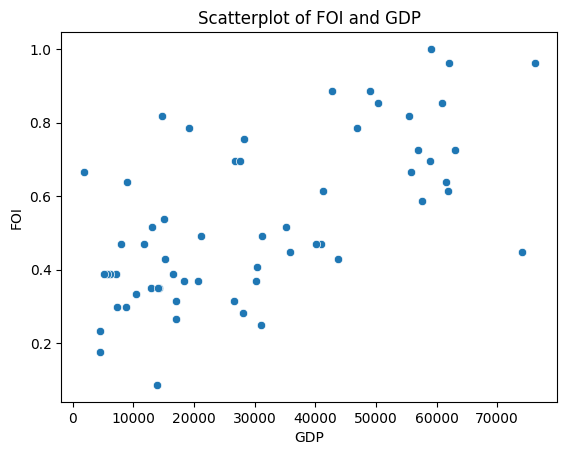

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=merged_df["NY.GDP.PCAP.PP.KD"], y=merged_df["FOI in 2014"])

plt.title("Scatterplot of FOI and GDP")
plt.xlabel("GDP")
plt.ylabel("FOI")

#### 3.2 Measure Pearson’s correlation

In the following chunk, calculate Pearson’s correlation coefficient between GDP and FOI.

For this you can use the [`pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) method of `scipy`.

In [10]:
from scipy.stats import pearsonr

correlation_coefficient = pearsonr(merged_df["NY.GDP.PCAP.PP.KD"], merged_df["FOI in 2014"])
correlation_coefficient

PearsonRResult(statistic=np.float64(0.6347951413070886), pvalue=np.float64(5.123502285123555e-08))

### To learn more
#### Check robustness
* What result do you get if you use other years? What if you choose one of the earliest years in Google trends?
* How do results change if you use a different threshod instead of 5 Million Internet users?
    
#### Test other hypotheses
* Is future orientation generating wealth? Or is wealth enabling to look more to the future?
* Is the FOI really measuring orientation to the future? Could it be something else?

## Part 2
## Using Google Trends data to model Flu Trends

### Install requirements. 

In [12]:
"""
! pip install -U pytrends
! pip install requests
! pip install statsmodels
"""

### Exercise 4 *(4 points)*
Use the [pytrends module](https://pypi.org/project/pytrends/) to get weekly Google Trends data concerning the [Flu/Influenza](https://en.wikipedia.org/wiki/Influenza) virus from the beginning of 2014 until the end of 2018. 
<br>

- Create an instance of the `TrendReq` class
- Find the appropriate query term. The TrendReq class includes a method `suggestions`, which should help you in this task (the query term can look like e.g. `/m/03x_m3v`).
- Specify the correct geographical region, the timeframe, and the key-word list. Use the `build_payload` method to store this information for future requests.
- Use the `interest_over_time` method to get the data.
<br><br>

***Hint:*** *the pytrends module currently has a bug. If you get a `TooManyRequestsError` despite following the documentation, try following the advice outlined [here](https://github.com/GeneralMills/pytrends/issues/573#issuecomment-1501897119) or [here](https://github.com/GeneralMills/pytrends/issues/561#issuecomment-1462899426) (both solve the issue).*

In [12]:
from pytrends.request import TrendReq

# create an instance of the TrendReq class
pytrends = TrendReq()

suggestions = pytrends.suggestions("Influenza")

# finding query term 
query_term = [term["mid"] for term in suggestions]

# getting the titles
titles = [title["title"] for title in suggestions]


# making a dataframe
pytrends.build_payload(kw_list=query_term, timeframe='2014-01-05 2018-12-31', geo='US')
df_4 = pytrends.interest_over_time()

# renaming the name of the columns
rename = dict(zip(query_term, titles))
df_4.rename(columns=rename, inplace=True)

In [13]:
df_4

,Influenza,Avian influenza,Swine influenza,Influenza vaccine,Common cold,isPartial
date,,,,,,
2014-01-05,35,1,7,9,22,False
2014-01-12,31,0,6,7,17,False
2014-01-19,24,0,4,5,18,False
2014-01-26,20,0,3,3,17,False
2014-02-02,13,0,2,2,14,False
...,...,...,...,...,...,...
2018-12-02,14,0,0,4,18,False
2018-12-09,15,0,0,4,19,False
2018-12-16,18,0,0,3,20,False


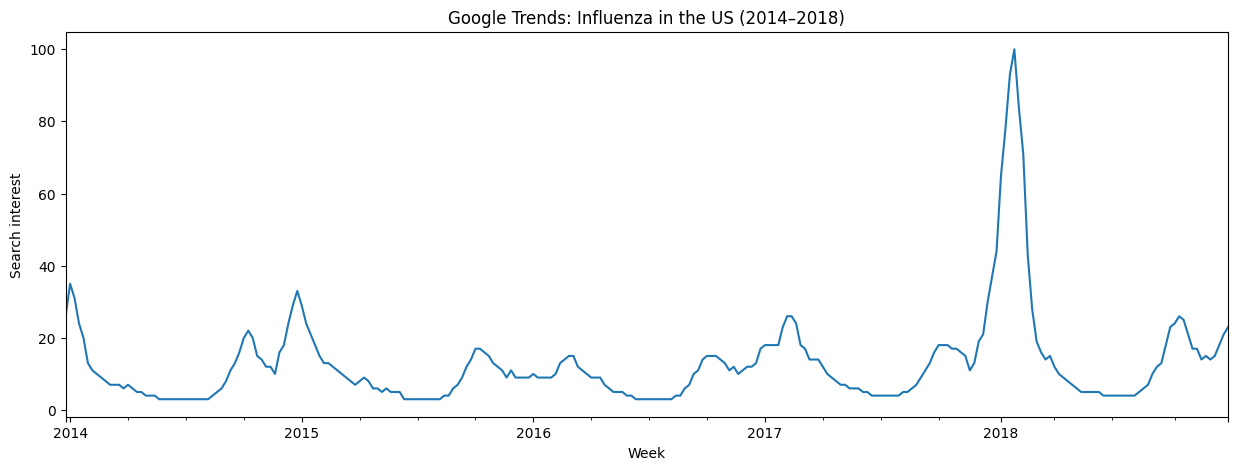

In [21]:
from pytrends.request import TrendReq

# create an instance of the TrendReq class
pytrends = TrendReq()

suggestions = pytrends.suggestions("Influenza")

# finding query term 
query_term = [term["mid"] for term in suggestions]

# getting the titles
titles = [title["title"] for title in suggestions]


# making a dataframe
pytrends.build_payload(kw_list=query_term, timeframe='2014-01-05 2018-12-31', geo='US')
df_4 = pytrends.interest_over_time()

# renaming the name of the columns
rename = dict(zip(query_term, titles))
df_4.rename(columns=rename, inplace=True)

# plot the resrch volume

# suggestions の中から「Influenza」に対応する topic を 1 つ選ぶ
# （title が Influenza のものを候補にし、type に disease があればそれを優先）
influenza_candidates = [
    s for s in suggestions
    if s["title"].lower() == "influenza"
]

influenza_topic = next(
    (s for s in influenza_candidates if "disease" in s.get("type", "").lower()),
    influenza_candidates[0]
)

query_term = influenza_topic["mid"]     # 例: /m/0cycc
topic_title = influenza_topic["title"]  # "Influenza"


pytrends.build_payload(
    kw_list=[query_term],
    timeframe="2014-01-01 2018-12-31",
    geo="US"
)


df_4 = pytrends.interest_over_time()


if "isPartial" in df_4.columns:
    df_4 = df_4.drop(columns="isPartial")


df_4 = df_4.rename(columns={query_term: "Influenza"})
df_4 = df_4.rename(columns={"Influenza": "Flu"})

# plot the search volume
plt.figure(figsize=(15, 5))
df_4["Flu"].plot(title="Google Trends: Influenza in the US (2014–2018)")
plt.ylabel("Search interest")
plt.xlabel("Week")
plt.show()




### Exercise 5 *(2 points)*

In the `a01` folder you will find a file named `ILINet.csv`, which contains data regarding the occurance of Influenza like Illnesses in the US. You can also find the data and the corresponding [documentation](https://gis.cdc.gov/grasp/fluview/FluViewPhase2QuickReferenceGuide.pdf) on the CDC's [FluView interactive dashboard](https://gis.cdc.gov/grasp/fluview/fluportaldashboard.html).
<br>
- Read the csv file, and store it as a [pandas](https://pypi.org/project/pandas/) dataframe. You might need to use the `skiprows` argument of the `read_csv` method to be able to load the data correctly.
- Select the columns named `YEAR`, `WEEK`, and `% WEIGHTED ILI` which will be needed for our analysis. Additionally, drop the rows which store observations from before 2014, or after 2018.

In [22]:
df_5 = pd.read_csv("ILINet.csv", skiprows=1)

# selecting the columns named YEAR, WEEK, and % WEIGHTED ILI
columns = ["YEAR", "WEEK", "% WEIGHTED ILI"]
df_5 = df_5[columns]

# droping the rows which store observations from before 2014, or after 2018
df_5 = df_5[(df_5["YEAR"] < 2019) & (df_5["YEAR"] > 2013)]

# putting 0 in week column
df_5["WEEK"] = [f"{number:02}" for number in df_5["WEEK"]]

# changing the type of the data
df_5["YEAR"] = df_5["YEAR"].astype(str)
df_5["WEEK"] = df_5["WEEK"].astype(str)

# making a column that has year and week 
df_5["WEEK"] = df_5["YEAR"] + "-" + df_5["WEEK"]

df_5

,YEAR,WEEK,% WEIGHTED ILI
848,2014,2014-01,4.28195
849,2014,2014-02,3.56288
850,2014,2014-03,3.36378
851,2014,2014-04,3.39659
852,2014,2014-05,3.11922
...,...,...,...
1104,2018,2018-48,2.14883
1105,2018,2018-49,2.25531
1106,2018,2018-50,2.64571
1107,2018,2018-51,3.14075


### Exercise 6 *(6 points)*

Next, we will use the [statsmodels](https://www.statsmodels.org/stable/index.html) module to build some models which can predict Flu infections. 
<br>
- Create an [autoregressive model](https://www.statsmodels.org/dev/generated/statsmodels.tsa.ar_model.AutoReg.html) using `% WEIGHTED ILI` as a dependent variable and it's [lagged](https://ibf.org/knowledge/glossary/lagged-dependent-variable-156) versions as explanatory variables. You are free to use as many lags as possible to find the best fitting model, as measured by the [Bayesian Information Criterion (BIC)](https://en.wikipedia.org/wiki/Bayesian_information_criterion).
- You may also add [trend](https://towardsdatascience.com/understanding-time-series-trend-addfd9d7764e) and/or [seasonal](https://towardsdatascience.com/seasonality-of-time-series-5b45b4809acd) variables to the model to improve your model's fit.
- Create another model with `% WEIGHTED ILI` as a dependent variable and the Google Trend volume from the same week as the explanatory variable.
- Last, create a model which uses both the lagged values of `% WEIGHTED ILI` and the Google Trends data (and/or its lagged versions) as explanatory variables to achieve the best fit. 
- Create a linechart showing the real values of `% WEIGHTED ILI` as well as the values predicted by all three models. Discuss your results.

In [23]:
# mergeing the data frame in exercise 4 and in exercise 5, and some unnecessary columns are dropped because the YYYY-WW did no match


# making a column that includs YYYY-WW to merge another dataframe in exercise 5 
df_4.index = pd.to_datetime(df_4.index)
df_4["Year"] = df_4.index
df_4["WEEK"] = df_4["Year"].dt.strftime("%Y-%U")

#merged_df_2 = pd.merge(df_4, df_5, on="WEEK", how="outer").dropna()

merged_df_2 = pd.merge(df_4, df_5, on="WEEK", how="outer")
merged_df_2 = merged_df_2[["Flu", "WEEK", "% WEIGHTED ILI"]]

# dropping the rows that include NaN
merged_df_2 = merged_df_2.dropna()

merged_df_2

,Flu,WEEK,% WEIGHTED ILI
1,35.0,2014-01,4.28195
2,31.0,2014-02,3.56288
3,24.0,2014-03,3.36378
4,20.0,2014-04,3.39659
5,13.0,2014-05,3.11922
...,...,...,...
258,14.0,2018-48,2.14883
259,15.0,2018-49,2.25531
260,18.0,2018-50,2.64571
261,21.0,2018-51,3.14075


c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312

Text(7, 80.7061402714586, 'lags: 2, BIC: 75.71')

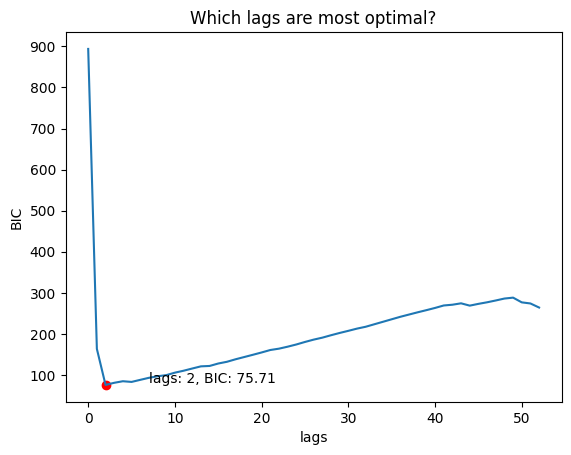

In [24]:

# Autoregressive model 



from statsmodels.tsa.ar_model import AutoReg

# getting the optimal lags
# optimal lags are 3

# x axis, lags
lags = [lag for lag in range(0,53)]


# y axis, BIC
BIC = [] 
for lag in range(0,53):
    ar_model = AutoReg(merged_df_2["% WEIGHTED ILI"], lags=lag, trend="c")
    results = ar_model.fit()
    BIC.append(results.bic)
        
# plot the graph
plt.plot(lags, BIC)
plt.title("Which lags are most optimal?")
plt.xlabel("lags")
plt.ylabel("BIC")


# clarifing the minimum BIC and the x value

# seeking the minimum BIC and the x value
minimum = min(BIC)
best_lag = BIC.index(minimum) 
# illustrating the point on the graph
plt.scatter(best_lag, minimum, color="red")
plt.annotate(text="lags: {}, BIC: {:.2f}".format(best_lag, round(minimum, 2)), xy=(best_lag, minimum), xytext=(best_lag+5, minimum+5))

In [25]:
# How about seasonality
# seasonal should be false according to this conclusion.

BIC_seasonal = []
for week in range(2,53):
    ar_model = AutoReg(endog=merged_df_2["% WEIGHTED ILI"], lags=2, trend="c", seasonal=True, period=week)
    results = ar_model.fit()
    BIC_seasonal.append(results.bic)

# All the BIC values are larger than 75.71(without setting seasonal), because the minimum BIC with seasonal was 79.35123459048573
min(BIC_seasonal)

# In this case, seasonal should not be False


c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312

np.float64(79.35123459048573)

In [26]:
# using best lags, autoregressive model output predicted values
ar_model = AutoReg(merged_df_2["% WEIGHTED ILI"], lags=best_lag, trend="c", seasonal=False)

results = ar_model.fit()

print(results.summary())

# prediction
pred_start = best_lag # Predictions can be obtained from the third value
pred_end = len(merged_df_2)
# gettingt predicted value
predictions_ar_model = results.predict(start=pred_start, end=pred_end)


                            AutoReg Model Results                             
Dep. Variable:         % WEIGHTED ILI   No. Observations:                  260
Model:                     AutoReg(2)   Log Likelihood                 -26.747
Method:               Conditional MLE   S.D. of innovations              0.268
Date:                Mon, 16 Mar 2026   AIC                             61.494
Time:                        15:15:45   BIC                             75.706
Sample:                             2   HQIC                            67.209
                                  260                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0850      0.030      2.850      0.004       0.027       0.144
% WEIGHTED ILI.L1     1.5009      0.053     28.497      0.000       1.398       1.604
% WEIGHTED ILI.L2    -0.

c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWa

In [27]:
# The model with `% WEIGHTED ILI` as a dependent variable and the Google Trend volume from the same week as the explanatory variable.


import statsmodels.api as sm

ols_model = sm.OLS(merged_df_2["% WEIGHTED ILI"], merged_df_2["Flu"])

results = ols_model.fit()

print(results.summary())


# prediction
predictions_google_trend = results.predict(merged_df_2["Flu"])

                                 OLS Regression Results                                
Dep. Variable:         % WEIGHTED ILI   R-squared (uncentered):                   0.822
Model:                            OLS   Adj. R-squared (uncentered):              0.821
Method:                 Least Squares   F-statistic:                              1194.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):                    5.69e-99
Time:                        15:15:48   Log-Likelihood:                         -367.10
No. Observations:                 260   AIC:                                      736.2
Df Residuals:                     259   BIC:                                      739.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [28]:
# Create a model which uses both the lagged values of `% WEIGHTED ILI` and the Google Trends data (and/or its lagged versions) as explanatory variables to achieve the best fit.  

exogenous_value = merged_df_2["Flu"]
mix_model = AutoReg(endog=merged_df_2["% WEIGHTED ILI"], exog=merged_df_2["Flu"], lags=best_lag,  trend="c")

results = mix_model.fit()

print(results.summary())


# predictions
results = mix_model.fit()
predictions_mix_model = results.predict()

                            AutoReg Model Results                             
Dep. Variable:         % WEIGHTED ILI   No. Observations:                  260
Model:                   AutoReg-X(2)   Log Likelihood                  -9.484
Method:               Conditional MLE   S.D. of innovations              0.251
Date:                Mon, 16 Mar 2026   AIC                             28.968
Time:                        15:15:48   BIC                             46.733
Sample:                             2   HQIC                            36.111
                                  260                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.1037      0.028      3.695      0.000       0.049       0.159
% WEIGHTED ILI.L1     1.2965      0.060     21.737      0.000       1.180       1.413
% WEIGHTED ILI.L2    -0.

c:\Users\Nutzer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [29]:
merged_df_2

,Flu,WEEK,% WEIGHTED ILI
1,35.0,2014-01,4.28195
2,31.0,2014-02,3.56288
3,24.0,2014-03,3.36378
4,20.0,2014-04,3.39659
5,13.0,2014-05,3.11922
...,...,...,...
258,14.0,2018-48,2.14883
259,15.0,2018-49,2.25531
260,18.0,2018-50,2.64571
261,21.0,2018-51,3.14075


([<matplotlib.axis.XTick at 0x1734cdcf170>,
 [Text(0, 0, '2014-01'),
  Text(50, 0, '2014-51'),
  Text(100, 0, '2015-49'),
  Text(150, 0, '2016-47'),
  Text(200, 0, '2017-45'),
  Text(250, 0, '2018-43')])

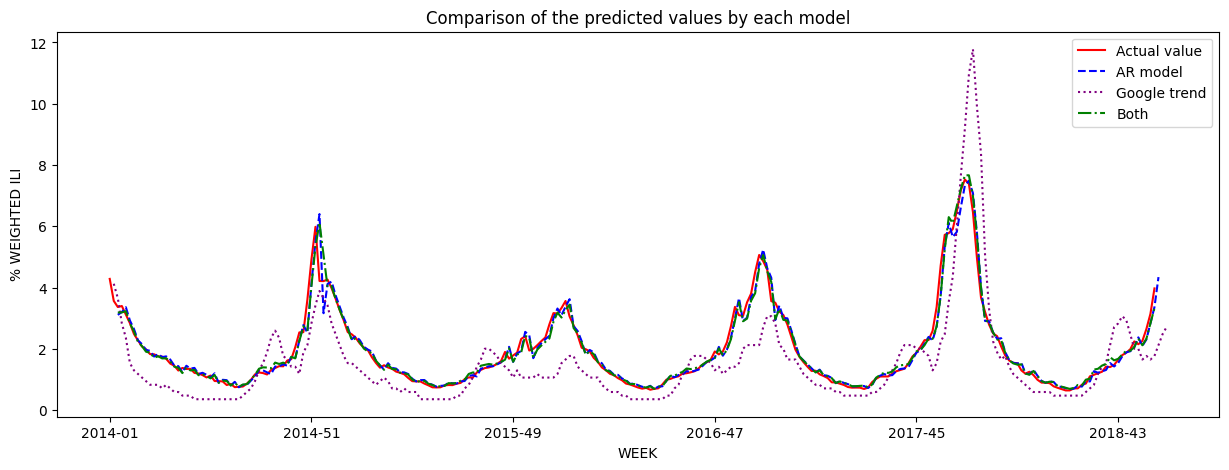

In [30]:
# drowing the graph

plt.figure(figsize=(15,5))


# plot the actual value
plt.plot(merged_df_2["WEEK"], merged_df_2['% WEIGHTED ILI'], label='Actual value', linestyle='-', color='red')

# plot the predicted values by the autoregressive model
plt.plot(predictions_ar_model, label='AR model', linestyle='--', color='blue')

# plot the predcited values by the google trend
plt.plot(predictions_google_trend, label='Google trend', linestyle=':', color='purple')

# plot the predcited values by the lagged % WEIGHTED ILI and google trend
plt.plot(predictions_mix_model, label='Both', linestyle='-.', color='green')


plt.title('Comparison of the predicted values by each model')
plt.xlabel('WEEK')
plt.ylabel('% WEIGHTED ILI')


plt.legend()


# adjusting the x axis
plt.xticks(np.arange(0,262, step=50))



**Interpretation</br>**
The autoregressive model and the model that is explained by the both of % WEIGHTED ILI lagged values and google trend could predict the values mostly perfect, while the google trend model fitted less well compared to other two models.

### To learn more
#### p-Hacking
* Try downloading data for other queries to see if you can improve the fit of your model.
    
#### Prediction
* Download the Google Trends data for 2019, and use your models to predict the values of `% WEIGHTED ILI`. Do the models make good predictions? Which model performs better?